## 1. Import Libraries

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import string
import csv
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /home/lenovo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/lenovo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /home/lenovo/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## 2. Import Preprocessed Data

In [91]:
path = "../preprocessed/reviews-mixed-stars.csv"
with open(path, newline="") as f:
    reader = csv.DictReader(f)
    data = list(reader)

data_df = pd.DataFrame(data)

# convert dates to datetime
data_df['at'] = pd.to_datetime(data_df['at'])

data_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,fde4f8c6-06c5-4d58-b5d8-2f12540509b6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,steam app great way interact friends access st...,5,6,3.10.9,2026-03-11 00:07:34,,,3.10.9
1,04c5e4af-4def-4458-a54b-9e8b825c77f6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,app website great customer support entirely un...,2,3,3.10.9,2026-03-14 06:24:17,,,3.10.9
2,b030ed42-5b10-4929-b8b3-ec7ac7233b67,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,bare minimum necessarily bad sense app essenti...,3,0,3.10.9,2026-03-22 00:43:35,,,3.10.9
3,c2e5379e-089d-49a7-9b12-a2911d8177d9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,absolutely useless steam pc problems able use ...,1,5,3.10.9,2026-03-10 12:03:24,,,3.10.9
4,6a993a5e-b43e-415a-8fc0-c8295ef0410d,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,pretty damn hard use website mobile easier con...,2,20,3.10.7,2026-02-05 21:19:55,,,3.10.7


## 3. Data Overview

### 3.1 Missing Values Analysis

In [92]:
missing_values = data_df.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
reviewId                0
userName                0
userImage               0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
replyContent            0
repliedAt               0
appVersion              0
dtype: int64


### 3.2 Review Score Distribution

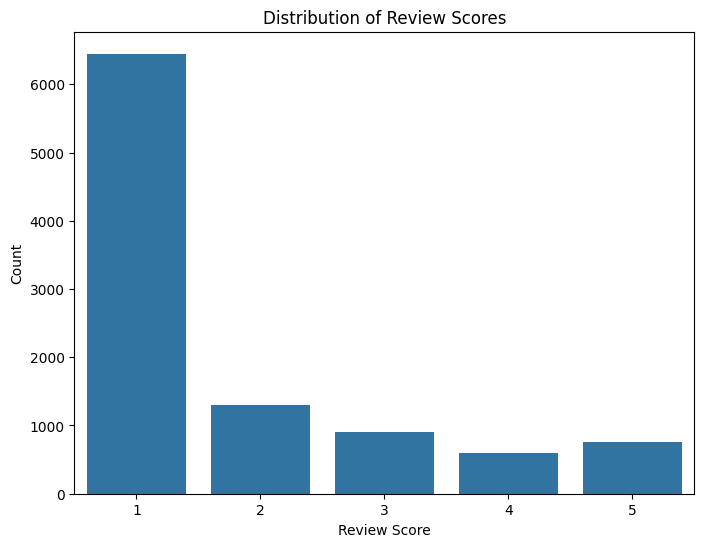

In [93]:
plt.figure(figsize=(8,6))
order = sorted(data_df['score'].unique())
sns.countplot(x=data_df['score'], order=order)
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


### 3.2 Review Trends Over Time

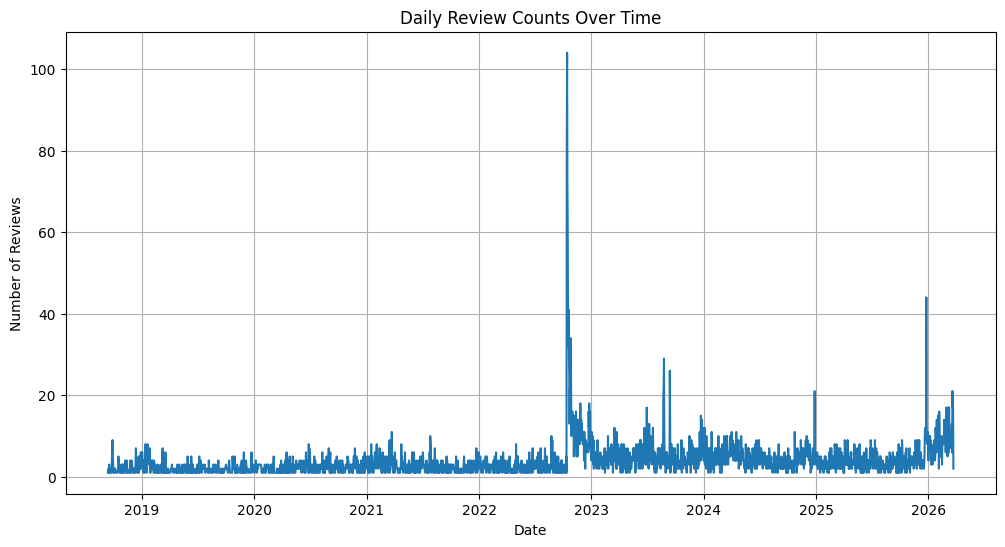

In [94]:
# Extract review date
data_df['review_date'] = data_df['at'].dt.date
review_trend = data_df.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()


<Figure size 640x480 with 0 Axes>

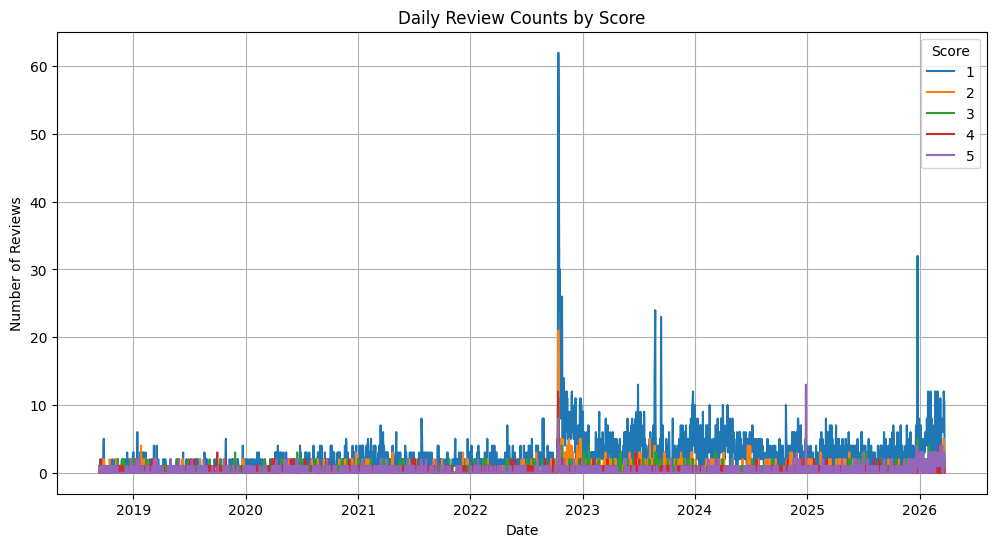

In [95]:
# Extract date
data_df['review_date'] = data_df['at'].dt.date

# Group by date AND score
review_trend = data_df.groupby(['review_date', 'score']).size().unstack(fill_value=0)

plt.figure()
review_trend.plot(figsize=(12, 6))

plt.title("Daily Review Counts by Score")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.legend(title="Score")

plt.show()

### 3.3 Word Clouds

3.3.1 Combined Word Cloud

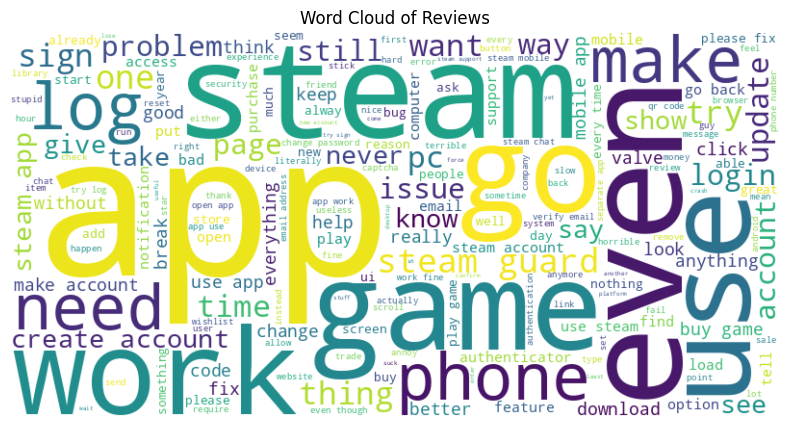

In [99]:
text = " ".join(data_df['content'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Reviews")

plt.show()

### 3.3.2 Positive Word Cloud

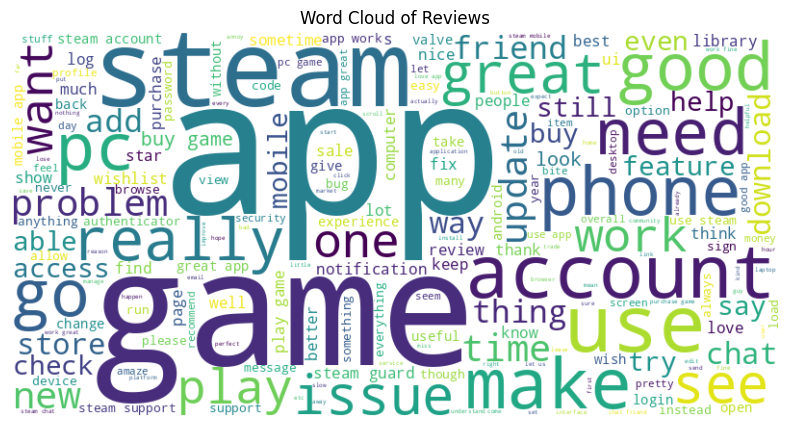

In [107]:
text = " ".join(data_df[(data_df['score'] == "5") | (data_df['score'] == "4")]['content'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Reviews")

plt.show()

### 3.3.3 Negative Word Cloud

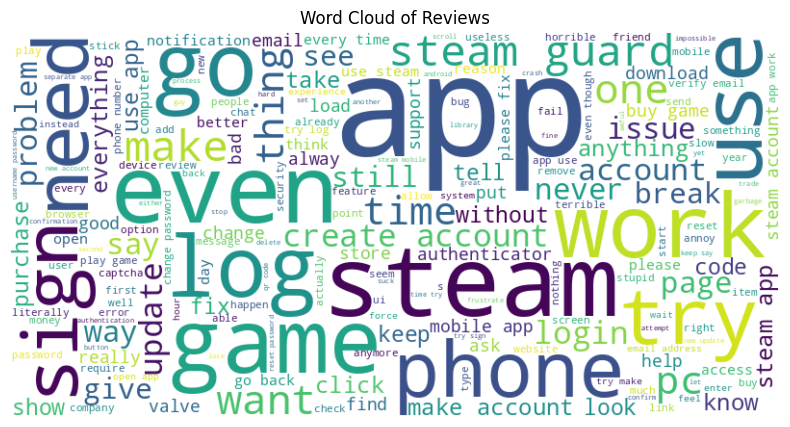

In [106]:
text = " ".join(data_df[(data_df['score'] == "1") | (data_df['score'] == "2")]['content'].dropna().astype(str))


wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Reviews")

plt.show()